<h2 align="center" style="color: red;">ATLIQO BANK CREDIT CARD A/B TESTING</h2>

<p align="center">
    <img src="./Analysis_imgs/age_group_distribution.png" width="300" height="300">
    <img src="./Analysis_imgs/payment_types_distribution_across_age_groups.png" width="300" height="300">
    <img src="./Analysis_imgs/age_groupwise_e_comm_platform_usage_for_purchase.png" width="300" height="300">
    <img src="./Analysis_imgs/annual_income_distribution_across_age_groups.png" width="300" height="300">
    <img src="./Analysis_imgs/occupation_distribution_across_agegroups.png" width="300" height="300">
    <img src="./Analysis_imgs/product_category_purchase_distribution_across_age_groups.png" width="300" height="300">
    <img src="./Analysis_imgs/agegroupwise_customer_location_distribution.png" width="300" height="300">
</p>

**Insights specific to customers with age-groups between 18-25 years:** 
1. People having age-group 18-25 years make up ~23.5% of the market. 
2. Usage of credit card amongst these group is much lower as compared to other groups. 
3. People falling with 18-25 years mostly prefer using **Amazon** to purchase primarily **Fashion and Apparel** items from. 
4. People within this age group mostly are **Freelancer's** residing in **cities**.

## PRE-CAMPAIGN 
To figure out the effectiveness of using the **new Atliqo Bank Credit Card** we need to setup **Target** & **Control** groups which means we have to determine the sizes of each of these groups depending on the **Statistical power** & **Effect Size** post discussion with business.

In [3]:
# import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [5]:
alpha = 0.05 # 5% significance level or probability of Type-I error i.e. wrong rejection of H0.
power = 0.8 # 80% statistical power in determining Type-2 error/ False Negative i.e. Wrong acceptance of H0.
effect_size = 0.2

# find sizes of control & target groups basis alpha, power & effect size
size = sms.tt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative='two-sided'
)

print(f'Number of customers needed in each of control & test groups is: {round(size)}')

Number of customers needed in each of control & test groups is: 393


Trial Run requires providing some sort of incentive to people in both set of control & test groups so they actually use the **old & new credit cards** to perform transactions. 

With **~393** sample size in each of the two groups it might be difficult for the company to run the trial owing to budgeting constraints. Hence below we find the **optimal sample size** for different **effect size** for both set of control & test groups which meets the budget of the company.

In [9]:
# Compute sample sizes for different effect sizes
effect_sizes = [0.1,0.2,0.3,0.4,0.5,1.0]
effect_and_sample_sizes = {n:sms.tt_ind_solve_power(effect_size=n,alpha=alpha,power=power,ratio=1,alternative='two-sided') for n in effect_sizes}

print(f'The effect and corresponding sample sizes are:\n {effect_and_sample_sizes}')

The effect and corresponding sample sizes are:
 {0.1: 1570.7330430520024, 0.2: 393.4056930002514, 0.3: 175.38466947045717, 0.4: 99.08032514658997, 0.5: 63.76561058785405, 1.0: 16.714722446954013}


Let's say business proposes to go with **effect size** of **0.4** for which the **sample size is ~100** which fits within the campaign budget as well.

### FORMING CONTROL AND TEST GROUPS
1. We identified let's say ~250 customers within the age group of 18-25 yrs. From this we choose 100 customers for initial campaign launch. 

2. Given campaign budget contraint it is run on 100 customers for a duration of 2 months. 

3. It could be that not all 100 customers we choose for **test group** to run the campaign use the **new credit card** to perform transactions despite the incentive offered. We consider a **conversion rate** of ~40% i.e. **40/100 people actually use credit card offered for transaction**. 

4. To maintain a **similar sample size** we create a **control group** of **40 customers** different from the ones in **test group**.

Hence from above the fix the sample sizes of each of the 2 groups to be **40**. 

*At the end of 2-month campaign period spanning 09-10-23 to 11-10-23 say we obtain daily data indicating **avg transaction amounts** made by the entire group of **40** customers in both control & test groups using **old** & **new** credit cards respectively.* 

*The **KPI** is to improve **avg transaction amounts** using **new** credit card*.

In [10]:
os.listdir()

['Analysis_imgs',
 'Atliqo_bank_credit_card_find_target_market.ipynb',
 'AB_Test_For_New_Credit_Card.ipynb']

In [11]:
# obtain avg daily transaction amount for the 2-months campaign duration for each of control & test groups resp.
avg_daily_transaction_amt_df = pd.read_csv('../Datasets/Atliqo_bank_dataset/avg_transactions_after_campaign.csv')
avg_daily_transaction_amt_df.head()

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,251.02,401.78
1,2023-09-11,250.77,326.16
2,2023-09-12,248.81,303.92
3,2023-09-13,255.90,363.29
4,2023-09-14,255.86,317.06


In [12]:
avg_daily_transaction_amt_df.shape

(62, 3)

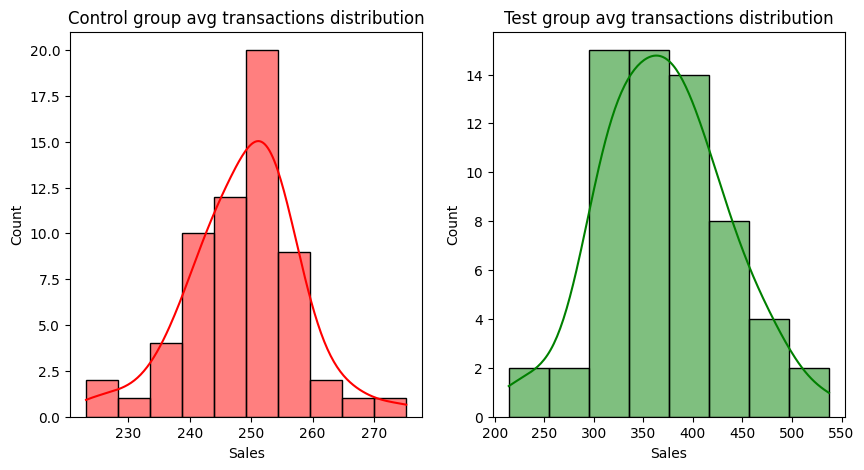

In [24]:
# plot distribution of avg daily transactions across 2 groups

fig,axes = plt.subplots(nrows=1,ncols=2)
fig.set_size_inches((10,5))
sns.histplot(data=avg_daily_transaction_amt_df,x='control_group_avg_tran',kde=True,ax=axes[0],color='red')
axes[0].set_title("Control group avg transactions distribution")
axes[0].set_xlabel('Sales')
sns.histplot(data=avg_daily_transaction_amt_df,x='test_group_avg_tran',kde=True,ax=axes[1],color='green')
axes[1].set_title("Test group avg transactions distribution")
axes[1].set_xlabel('Sales')
plt.show()

In [25]:
# find num of days on which control group transaction > test group
days_with_ctrl_grp_transactions_larger_than_test = avg_daily_transaction_amt_df.loc[avg_daily_transaction_amt_df['control_group_avg_tran']>avg_daily_transaction_amt_df['test_group_avg_tran']].shape[0]
print(f'Percentage of days with higher control group avg daily transactions compared to test group is: {(days_with_ctrl_grp_transactions_larger_than_test/avg_daily_transaction_amt_df.shape[0])*100}%')

Percentage of days with higher control group avg daily transactions compared to test group is: 3.225806451612903%


### HYPOTHESIS TESTING

In [26]:
# compute control & test group mean & std deviations resp
control_mean = avg_daily_transaction_amt_df['control_group_avg_tran'].mean()
control_std_dev = avg_daily_transaction_amt_df['control_group_avg_tran'].std()

test_mean = avg_daily_transaction_amt_df['test_group_avg_tran'].mean()
test_std_dev = avg_daily_transaction_amt_df['test_group_avg_tran'].std()

In [27]:
(control_mean,control_std_dev)

(np.float64(248.94129032258064), np.float64(9.137869049553624))

In [28]:
(test_mean,test_std_dev)

(np.float64(370.5364516129033), np.float64(63.25415113953286))

In [29]:
sample_size = avg_daily_transaction_amt_df.shape[0]
sample_size

62

Since **sample_size** >= 30 as per **Central Limit Theorem** we may use **sample std dev in place of population std dev** to compute **z-scores**.

In [30]:
z_score = abs(control_mean-test_mean)/np.sqrt((control_std_dev**2/sample_size) + (test_std_dev**2/sample_size))
z_score

np.float64(14.98090307099052)

In [31]:
# compute critical z_score for one-tailed test
z_critical = st.norm.ppf(1-alpha)
z_critical

np.float64(1.644853626951472)

In [33]:
bool(z_score > z_critical)

True

From above we find that since **z-score > z-critical** we can reject the **Null hypothesis** and accept the **alternate hypothesis** which says **The new credit card indeed improves transactions**.